# EDA — SmartSeq datasets

This notebook explores the **SmartSeq** scRNA-seq data for the two cell lines
used in the AI Lab challenge:

- **MCF7** — luminal breast cancer cell line (ER+, hormone-responsive)
- **HCC1806** — basal-like / triple-negative breast cancer cell line

Each cell line was cultured under two oxygen conditions:

- **Norm** — ~21% O2 (normoxia, control)
- **Hypo** — ~1% O2 (hypoxia, treatment)

SmartSeq is a low-throughput, full-length sequencing protocol (hundreds of cells,
no UMIs). For each cell line we have three flavours of the count matrix —
`Unfiltered`, `Filtered`, and `Filtered_Normalised_3000` — and a
tab-delimited `MetaData.tsv` linking each BAM filename to its condition.

> Aim: characterise the data (size, sparsity, label balance), look for issues
> (missing values, duplicates, outliers, non-normality) and decide what
> preprocessing the downstream analyses can rely on.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))
from src.utils import load_smartseq, load_dropseq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
RNG = 24

In [2]:
CELL_LINES = ["MCF7", "HCC1806"]

## 1 — Metadata overview

In [3]:
metas = {}
for cl in CELL_LINES:
    m = pd.read_csv(f"../../datasets/SmartSeq/{cl}_SmartS_MetaData.tsv", sep="\t", index_col=0)
    metas[cl] = m
    print(f"{cl}: {m.shape[0]} rows, columns = {m.columns.tolist()}")
metas["MCF7"].head(3)

MCF7: 383 rows, columns = ['Cell Line', 'Lane', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']
HCC1806: 243 rows, columns = ['Cell Line', 'PCR Plate', 'Pos', 'Condition', 'Hours', 'Cell name', 'PreprocessingTag', 'ProcessingComments']


,Cell Line,Lane,Pos,Condition,Hours,Cell name,PreprocessingTag,ProcessingComments
Filename,,,,,,,,
output.STAR.1_A10_Hypo_S28_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A10,Hypo,72,S28,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.1_A11_Hypo_S29_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A11,Hypo,72,S29,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"
output.STAR.1_A12_Hypo_S30_Aligned.sortedByCoord.out.bam,MCF7,output.STAR.1,A12,Hypo,72,S30,Aligned.sortedByCoord.out.bam,"STAR,FeatureCounts"


In [4]:
# Class balance across the two cell lines.
balance = pd.DataFrame({cl: m["Condition"].replace({"Normo": "Norm"}).value_counts() for cl, m in metas.items()}).T
balance["total"] = balance.sum(axis=1)
balance

Condition,Hypo,Norm,total
MCF7,191,192,383
HCC1806,126,117,243


Both cell lines are roughly balanced between Hypo and Norm — useful for
classification (no need for heavy resampling). HCC1806 uses the label `Normo`
while MCF7 uses `Norm`; our loader collapses both to `Norm`.

## 2 — Compare Unfiltered → Filtered → Filtered+Normalised (MCF7)

In [5]:
# Look at the three SmartSeq variants for MCF7 to understand what preprocessing has been applied.
X_unf, _ = load_smartseq("MCF7", variant="unfiltered")
X_flt, _ = load_smartseq("MCF7", variant="filtered")
X_fln, y_fln = load_smartseq("MCF7", variant="filtered_normalised")
for name, X in [("Unfiltered", X_unf), ("Filtered", X_flt), ("Filtered+Norm 3000", X_fln)]:
    print(f"{name:22s} shape (cells x genes) = {X.shape}")

Unfiltered             shape (cells x genes) = (383, 22934)
Filtered               shape (cells x genes) = (313, 18945)
Filtered+Norm 3000     shape (cells x genes) = (250, 3000)


In [6]:
# Sparsity and dynamic range comparison.
stats = []
for name, X in [("Unfiltered", X_unf), ("Filtered", X_flt), ("Filtered+Norm", X_fln)]:
    vals = X.values
    stats.append(
        {
            "variant": name,
            "n_cells": X.shape[0],
            "n_genes": X.shape[1],
            "%zeros": (vals == 0).mean() * 100,
            "min": vals.min(),
            "median": np.median(vals),
            "max": vals.max(),
        }
    )
pd.DataFrame(stats).set_index("variant")

,n_cells,n_genes,%zeros,min,median,max
variant,,,,,,
Unfiltered,383,22934,60.215316,0,0.0,190556
Filtered,313,18945,47.157561,0,1.0,190556
Filtered+Norm,250,3000,63.622133,0,0.0,107556


Three observations to highlight in the report:

1. **Gene filtering**: the unfiltered matrix has tens of thousands of features,
   the normalised one keeps only the top 3000 highly-variable genes — a
   drastic dimensionality reduction.
2. **Sparsity**: even SmartSeq is sparse (lots of zeros), although less than
   DropSeq. The filtered+normalised flavour is denser because zero-only genes
   were dropped.
3. **Dynamic range**: unfiltered are raw integer counts (range 0 → millions);
   filtered+normalised is on a log-scale (range ~0–10). Distributions are
   therefore not directly comparable.

## 3 — Distribution shapes (per-cell, on the normalised matrix)

/tmp/ipykernel_8864/381197918.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


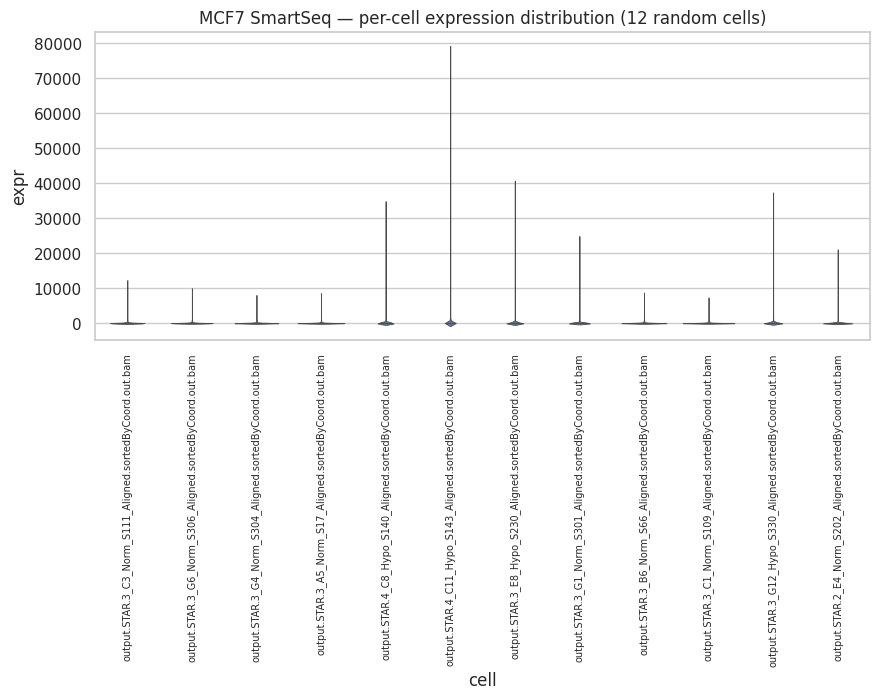

In [7]:
# Plot per-cell expression distribution (random sample of 12 cells) to spot
# outlier cells or weird shapes.
rng = np.random.default_rng(RNG)
sample = rng.choice(X_fln.index, size=12, replace=False)
long = X_fln.loc[sample].T.melt(var_name="cell", value_name="expr")
plt.figure(figsize=(10, 4))
sns.violinplot(data=long, x="cell", y="expr", inner="quartile", linewidth=0.6)
plt.xticks(rotation=90, fontsize=7)
plt.title("MCF7 SmartSeq — per-cell expression distribution (12 random cells)")
plt.tight_layout()
plt.show()

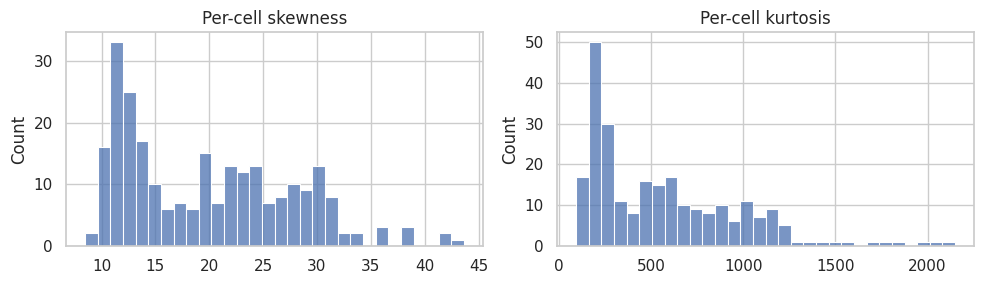

median skew = 19.66,  median kurtosis = 475.78


In [8]:
# Skewness and kurtosis per cell, as a sanity check that the log-normalised data is closer to symmetric.
from scipy import stats as sps

skew = X_fln.apply(lambda r: sps.skew(r), axis=1)
kurt = X_fln.apply(lambda r: sps.kurtosis(r), axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(skew, ax=axes[0], bins=30)
axes[0].set_title("Per-cell skewness")
sns.histplot(kurt, ax=axes[1], bins=30)
axes[1].set_title("Per-cell kurtosis")
plt.tight_layout()
plt.show()
print(f"median skew = {skew.median():.2f},  median kurtosis = {kurt.median():.2f}")

A normal distribution has skewness 0 and kurtosis 0 (Fisher's definition).
Even after log-normalisation the per-cell distributions remain right-skewed
because most genes are still close to zero (many low-expression genes
dominate the centre of the distribution).

## 4 — Sample-sample correlation

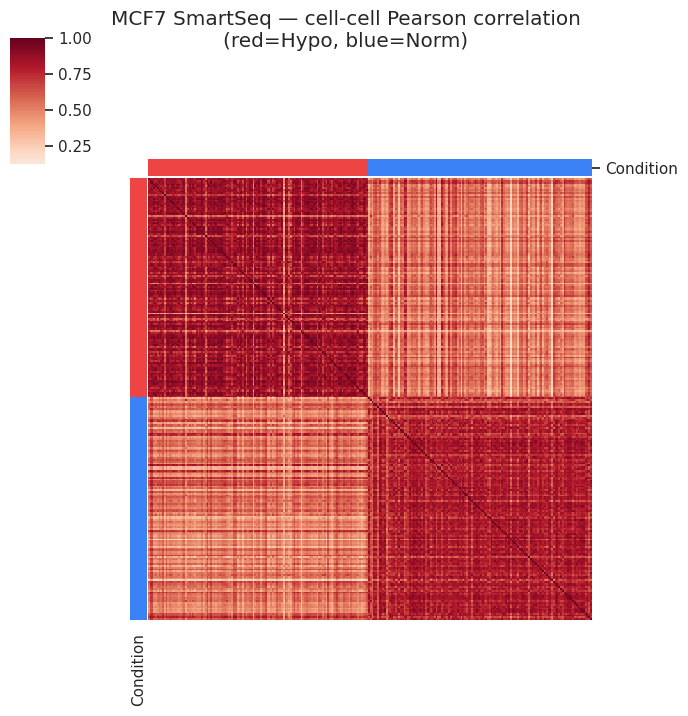

In [9]:
# Cells from the same condition should have higher correlation with each other
# than with cells from the opposite condition. We test that visually.
# We sort cells by condition and look at the cell-cell correlation matrix.
order = y_fln.sort_values().index
corr = X_fln.loc[order].T.corr()
cond_colors = y_fln.loc[order].map({"Norm": "#3b82f6", "Hypo": "#ef4444"})
g = sns.clustermap(
    corr,
    row_cluster=False,
    col_cluster=False,
    row_colors=cond_colors,
    col_colors=cond_colors,
    cmap="RdBu_r",
    center=0,
    figsize=(7, 7),
    xticklabels=False,
    yticklabels=False,
)
g.fig.suptitle("MCF7 SmartSeq — cell-cell Pearson correlation\n(red=Hypo, blue=Norm)", y=1.02)
plt.show()

If a block-like structure emerges along the diagonal (cells of the same
condition correlate more strongly with each other) we already have a hint
that hypoxia leaves a transcriptional signature detectable from these 3000
genes — that's what unsupervised clustering will quantify.

## 5 — Duplicates

In [10]:
# Are there duplicate genes (rows) or cells (columns)? Duplicates can leak between train/test or bias models.
for name, X in [("Unfiltered", X_unf), ("Filtered", X_flt), ("Filtered+Norm", X_fln)]:
    dup_cells = X.index.duplicated().sum()
    dup_genes = X.columns.duplicated().sum()
    print(f"{name:18s} duplicated cells={dup_cells}  duplicated genes={dup_genes}")

Unfiltered         duplicated cells=0  duplicated genes=0
Filtered           duplicated cells=0  duplicated genes=0
Filtered+Norm      duplicated cells=0  duplicated genes=0


## 6 — HCC1806 — same checks, condensed

HCC1806 filtered+norm: (182, 3000)  labels: {'Hypo': 97, 'Norm': 85}


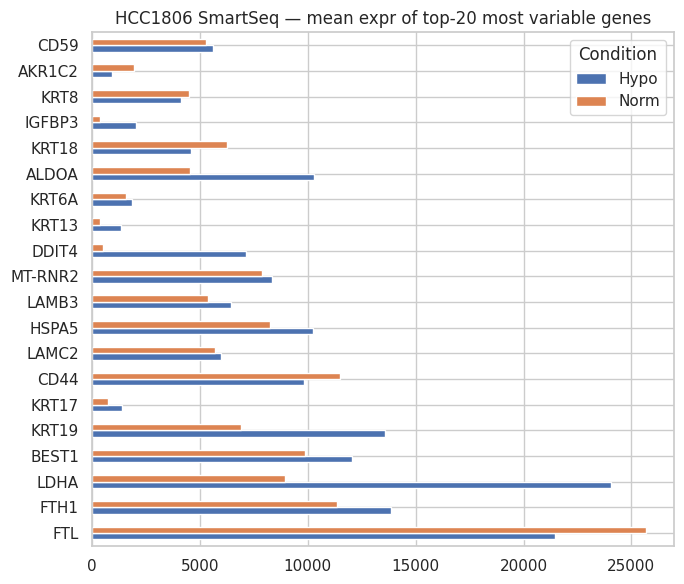

In [11]:
Xh, yh = load_smartseq("HCC1806", variant="filtered_normalised")
print("HCC1806 filtered+norm:", Xh.shape, " labels:", yh.value_counts().to_dict())

# Quick visual: per-condition mean expression (top 20 most variable genes).
gene_var = Xh.var(axis=0).sort_values(ascending=False)
top_genes = gene_var.head(20).index
mean_by_cond = Xh[top_genes].groupby(yh).mean().T
mean_by_cond.plot.barh(figsize=(7, 6), title="HCC1806 SmartSeq — mean expr of top-20 most variable genes")
plt.tight_layout()
plt.show()

## 7 — Biological sanity check: known hypoxia markers

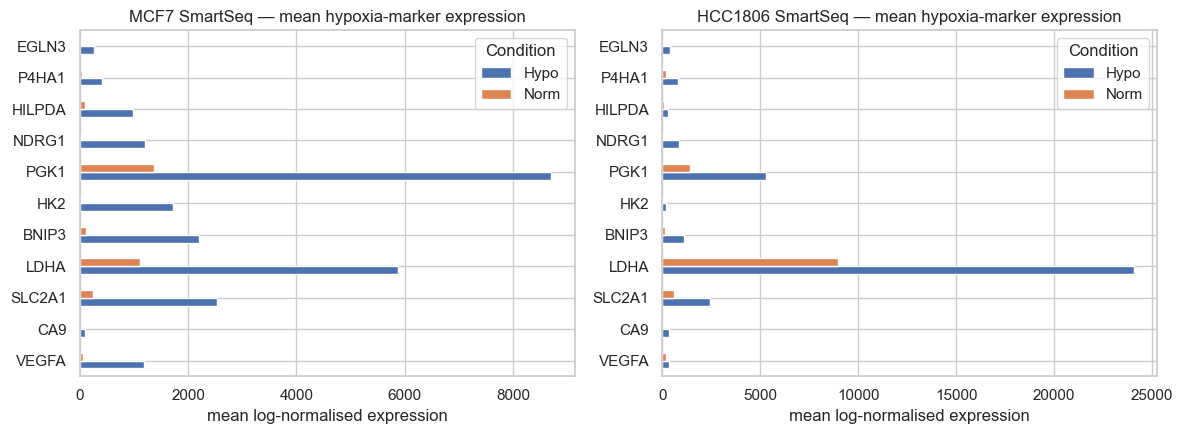

In [12]:
# Canonical hypoxia-induced genes (HIF-1 targets). If the data captures real
# hypoxia biology — and not just a technical batch axis — these should be
# systematically higher in Hypo than in Norm cells.
MARKERS = ["VEGFA", "CA9", "SLC2A1", "LDHA", "BNIP3", "HK2", "PGK1", "NDRG1", "HILPDA", "P4HA1", "EGLN3"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cl in zip(axes, CELL_LINES):
    X, y = load_smartseq(cl)
    present = [m for m in MARKERS if m in X.columns]
    X[present].groupby(y).mean().T.plot.barh(ax=ax)
    ax.set_title(f"{cl} SmartSeq — mean hypoxia-marker expression")
    ax.set_xlabel("mean log-normalised expression")
plt.tight_layout()
plt.show()

These HIF-1 target genes are consistently **up in Hypo** cells in both cell
lines — a reassuring confirmation that (a) the condition labels are correct and
(b) the 3000-HVG SmartSeq matrix retains the very signal we want to classify.
We will check in notebook 02 whether this signal is also the *dominant* axis of
unsupervised variation.

## 8 — Takeaways for the report

- SmartSeq gives us **~200 high-quality cells per cell line** with ~3000
  HVGs after the teacher's preprocessing. Balanced label distribution.
- The provided filtered+normalised matrix is **log-transformed** — directly
  usable as input to PCA / scanpy without further log1p.
- We still see residual skew and a handful of high-correlation cell pairs
  (likely technical replicates from the same plate well).
- Cell-cell correlation already hints at a condition-driven structure —
  good prognosis for the unsupervised separation in notebook 02.